# Multi-Agent Formation Control PoC — v2: LangGraph StateGraph

This notebook implements the **Formation Control** pattern using a proper **LangGraph `StateGraph`**
with named nodes, typed `MissionState`, `InMemorySaver` checkpointing, and **dynamic drone dispatch
decided by the Gemini LLM**.

### Architecture (6-node StateGraph)
```
START → assess_mission → plan_swarm (LLM) → dispatch_simulation
      → analyze_telemetry → persist_telemetry (SQLite) → generate_verdict (LLM) → END
```

### Key Differences from v1
| Feature | v1 | v2 |
|---|---|---|
| Agent pattern | `create_agent` black-box loop | Explicit `StateGraph` nodes |
| Drone count | Hardcoded 5 | **LLM decides (3–8)** |
| Formation | Fixed grid | **LLM decides: line / v_shape / grid** |
| Memory | `MemorySaver` | `InMemorySaver` checkpointer |
| Telemetry storage | None | **SQLite `data/telemetry.db`** |
| State | Implicit | Typed `MissionState` TypedDict |

### Tech Stack
- **LangGraph** `StateGraph` + `InMemorySaver` — orchestration + short-term memory
- **Google Gemini** `gemini-3.5-flash` — swarm planning + FDS verdict (structured output)
- **MLflow** on Databricks — autologged traces (experiment `3192447675404693`)
- **SQLite** — persistent cross-session mission telemetry


In [1]:
import os
import math
import time
import json
import sqlite3
import uuid
from datetime import datetime, timezone
from typing import TypedDict, Optional, List, Tuple, Dict, Any

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
from pydantic import BaseModel, Field

import mlflow
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langchain_google_genai import ChatGoogleGenerativeAI

print("All dependencies loaded successfully.")


/Users/vasim/Programming/ai-engineering/mas-formation-control/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All dependencies loaded successfully.


In [2]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite"
)
llm.invoke("hi")

AIMessage(content=[{'type': 'text', 'text': 'Hi there! How can I help you today?', 'extras': {'signature': 'EjQKMgERTTIPqw7no9N212Kyda+FJdZ6vGuZC5gBb57qHWDHuBQ/Fx1E7Otb9VeKoEUhPWAO'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019fe77f-3f56-71e2-ac8c-6fb8cd505cc1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2, 'output_tokens': 10, 'total_tokens': 12, 'input_token_details': {'cache_read': 0}})

In [3]:
# Load .env → MLFLOW_TRACKING_URI=databricks, MLFLOW_EXPERIMENT_ID, GOOGLE_API_KEY, DATABRICKS_*
load_dotenv(".env", override=True)

MLFLOW_EXPERIMENT_ID = os.environ.get("MLFLOW_EXPERIMENT_ID", "3192447675404693")
mlflow.set_tracking_uri(os.environ.get("MLFLOW_TRACKING_URI", "databricks"))
experiment = mlflow.set_experiment(experiment_id=MLFLOW_EXPERIMENT_ID)
print(f"[MLflow] Connected → Experiment ID: {MLFLOW_EXPERIMENT_ID} on Databricks")

# Autolog captures all LangChain/LangGraph LLM calls, tool calls, and traces automatically
mlflow.langchain.autolog()

# Gemini LLM setup
GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY", os.environ.get("GOOGLE_API_KEY", ""))
CHAT_MODEL_NAME = "gemini-3.5-flash-lite"

llm = None
if GEMINI_API_KEY:
    try:
        llm = init_chat_model(
            CHAT_MODEL_NAME,
            model_provider="google_genai",
            api_key=GEMINI_API_KEY,
            timeout=60,
        )
        print(f"[Google Gemini] Model: {CHAT_MODEL_NAME} | Status: Connected")
    except Exception as e:
        print(f"[Google Gemini] Init note: {e}. Deterministic fallback active.")
else:
    print("[Google Gemini] GOOGLE_API_KEY not set — deterministic fallback mode.")


[MLflow] Connected → Experiment ID: 3192447675404693 on Databricks
[Google Gemini] Model: gemini-3.5-flash-lite | Status: Connected


If you are using MLflow Tracing, you can migrate your traces to Unity Catalog for unlimited storage, fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/migrate-traces-to-uc


In [4]:
llm.invoke("hi")

AIMessage(content=[{'type': 'text', 'text': 'Hi there! How can I help you today?', 'extras': {'signature': 'EjQKMgERTTIPZ1V2ccJoG24JQxHCgd5ud6jhZULHni/jaoR41q9RcjZ04lu8KCTevSMAELGq'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019fe77f-5565-7b53-acc5-a294acd925bd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2, 'output_tokens': 10, 'total_tokens': 12, 'input_token_details': {'cache_read': 0}})

In [5]:
class Vector:
    """2D vector for drone positions and offsets."""
    def __init__(self, x: float, y: float):
        self.x = x
        self.y = y

    def __add__(self, other):  return Vector(self.x + other.x, self.y + other.y)
    def __sub__(self, other):  return Vector(self.x - other.x, self.y - other.y)
    def __mul__(self, scalar): return Vector(self.x * scalar, self.y * scalar)
    def __repr__(self):        return f"Vector({self.x:.2f}, {self.y:.2f})"

    def norm(self):
        return math.sqrt(self.x ** 2 + self.y ** 2)

    def normalized(self):
        n = self.norm()
        return Vector(self.x / n, self.y / n) if n > 1e-9 else Vector(0.0, 0.0)

    def clamp(self, max_speed: float):
        n = self.norm()
        if n > max_speed:
            return self.normalized() * max_speed
        return Vector(self.x, self.y)

def NORM(v: Vector) -> float:
    return v.norm()

print("Vector class defined.")


Vector class defined.


In [6]:
# ── Pydantic: LLM's swarm dispatch decision ────────────────────────────────
class SwarmDispatchPlan(BaseModel):
    num_drones: int   = Field(description="Number of drones to dispatch (3–8)")
    formation_type: str = Field(description="Formation layout: 'line', 'v_shape', or 'grid'")
    spacing_m: float  = Field(description="Inter-drone spacing in metres (recommended 8–12)")
    justification: str = Field(description="Reasoning behind this swarm configuration")

# ── Pydantic: FDS compliance verdict ──────────────────────────────────────
class FDSStageVerdict(BaseModel):
    stage_name: str = Field(description="Name of the FDS verification stage")
    passed: bool    = Field(description="Whether this stage passed")
    details: str    = Field(description="Technical details of the stage evaluation")

class FDSVerificationVerdict(BaseModel):
    formation_rule_verified:      FDSStageVerdict = Field(description="Stage 1: 10m grid spacing")
    coordinated_movement_verified: FDSStageVerdict = Field(description="Stage 2: Swarm follows leader")
    dynamic_adaptation_verified:  FDSStageVerdict = Field(description="Stage 3: Obstacle avoidance")
    self_organization_verified:   FDSStageVerdict = Field(description="Stage 4: Peer yielding")
    re_formation_verified:        FDSStageVerdict = Field(description="Stage 5: Grid re-convergence")
    overall_mission_success: bool = Field(description="True if all stages passed")
    executive_summary: str        = Field(description="Comprehensive technical summary")

# ── LangGraph shared state TypedDict ───────────────────────────────────────
class MissionState(TypedDict):
    # Mission inputs
    mission_brief:   str
    field_width_m:   float
    field_height_m:  float
    obstacles:       List[dict]          # [{x, y, radius}]
    # Agent decision (plan_swarm node)
    dispatch_plan:   dict                # SwarmDispatchPlan.model_dump()
    # Simulation output (dispatch_simulation node)
    sim_telemetry_json: str
    # Analysis output (analyze_telemetry node)
    analysis_metrics: dict
    # Persistence output (persist_telemetry node)
    run_id: str
    # Verdict output (generate_verdict node)
    verdict: dict                        # FDSVerificationVerdict.model_dump()

print("Pydantic schemas and MissionState TypedDict defined.")


Pydantic schemas and MissionState TypedDict defined.


In [7]:
class CircularObstacle:
    def __init__(self, x: float, y: float, radius: float):
        self.position = Vector(x, y)
        self.radius = radius

class DroneAgent:
    def __init__(
        self,
        agent_id: str,
        initial_position: Vector,
        designated_offset: Vector,
        neighbor_id: Optional[str] = None,
        kp: float = 1.4,
        tolerance: float = 0.2,
        max_speed: float = 5.0
    ):
        self.agent_id = agent_id
        self.position = initial_position
        self.velocity = Vector(0.0, 0.0)
        self.DESIGNATED_OFFSET = designated_offset
        self.neighbor_id = neighbor_id
        self.kp = kp
        self.TOLERANCE = tolerance
        self.max_speed = max_speed
        self.is_avoiding = False
        self.trajectory: List[Tuple[float, float]] = [(self.position.x, self.position.y)]

    def update_control_loop(self, dt: float, swarm: Dict[str, 'DroneAgent'], obstacles: List[CircularObstacle]):
        # Obstacle avoidance
        f_obs = Vector(0.0, 0.0)
        self.is_avoiding = False
        for obs in obstacles:
            delta = self.position - obs.position
            dist = delta.norm()
            safety_margin = obs.radius + 3.0
            if dist < safety_margin:
                self.is_avoiding = True
                repulsion = delta.normalized() * (safety_margin - dist) * 5.0
                tangent = Vector(-delta.normalized().y, delta.normalized().x) * 4.0
                f_obs = f_obs + repulsion + tangent

        # Formation control
        if self.neighbor_id and self.neighbor_id in swarm:
            neighbor_pos = swarm[self.neighbor_id].position
            desired_position = neighbor_pos + self.DESIGNATED_OFFSET
            position_error = desired_position - self.position

            # Peer yielding (self-organization)
            f_peer = Vector(0.0, 0.0)
            for peer_id, peer in swarm.items():
                if peer_id != self.agent_id:
                    p_delta = self.position - peer.position
                    p_dist = p_delta.norm()
                    if p_dist < 4.5 and p_dist > 1e-3:
                        f_peer = f_peer + p_delta.normalized() * (4.5 - p_dist) * 3.0

            if NORM(position_error) > self.TOLERANCE:
                adj = position_error * self.kp
                if self.is_avoiding:
                    self.velocity = (self.velocity + (f_obs * 1.5 + adj * 0.2 + f_peer) * dt).clamp(self.max_speed)
                else:
                    self.velocity = (self.velocity + (adj + f_peer) * dt).clamp(self.max_speed)
            else:
                if self.is_avoiding:
                    self.velocity = (self.velocity + f_obs * dt).clamp(self.max_speed)
                else:
                    self.velocity = self.velocity * 0.98
        else:
            if self.is_avoiding:
                self.velocity = (self.velocity + f_obs * dt).clamp(self.max_speed)

        self.position = self.position + self.velocity * dt
        self.trajectory.append((self.position.x, self.position.y))


def build_swarm_formation(
    num_drones: int,
    formation_type: str,
    spacing_m: float,
) -> List[Tuple[str, Vector, Vector, Optional[str]]]:
    """
    Builds a list of (agent_id, initial_pos, designated_offset, neighbor_id) tuples.
    Leader is always Drone_A at (20.0, 10.0). All followers track Drone_A.
    Formations:
      line    — column behind leader along Y axis
      v_shape — alternating left/right diagonal wings
      grid    — rectangular MxN grid behind leader
    """
    leader_pos = Vector(20.0, 10.0)
    agents = [("Drone_A", leader_pos, Vector(0.0, 0.0), None)]

    offsets: List[Vector] = []

    if formation_type == "line":
        for i in range(1, num_drones):
            offsets.append(Vector(0.0, -i * spacing_m))

    elif formation_type == "v_shape":
        for i in range(1, num_drones):
            side = 1 if i % 2 == 1 else -1
            row  = (i + 1) // 2
            offsets.append(Vector(side * row * spacing_m * 0.8, -row * spacing_m * 0.8))

    else:  # grid (default)
        cols = max(2, int(math.ceil(math.sqrt(num_drones - 1))))
        r, c = 0, 0
        for _ in range(1, num_drones):
            x_off = (c - (cols - 1) / 2.0) * spacing_m
            y_off = -(r + 1) * spacing_m
            offsets.append(Vector(x_off, y_off))
            c += 1
            if c >= cols:
                c = 0; r += 1

    drone_names = [f"Drone_{chr(65 + i)}" for i in range(1, num_drones)]
    for name, offset in zip(drone_names, offsets):
        init_pos = leader_pos + offset
        agents.append((name, init_pos, offset, "Drone_A"))

    return agents

print("DroneAgent, CircularObstacle, and build_swarm_formation() defined.")


DroneAgent, CircularObstacle, and build_swarm_formation() defined.


In [8]:
@tool
def run_swarm_simulation_tool(
    num_drones: int = 5,
    formation_type: str = "grid",
    spacing_m: float = 10.0,
    sim_steps: int = 160,
    dt: float = 0.1,
) -> str:
    """
    Runs the decentralized agricultural drone swarm simulation.
    Spawns num_drones in the specified formation (line/v_shape/grid).
    Returns JSON-serialized step-by-step telemetry records.
    """
    agent_specs = build_swarm_formation(num_drones, formation_type, spacing_m)
    swarm: Dict[str, DroneAgent] = {}
    for agent_id, init_pos, offset, neighbor_id in agent_specs:
        swarm[agent_id] = DroneAgent(agent_id, init_pos, offset, neighbor_id)

    leader = swarm["Drone_A"]
    obstacles = [CircularObstacle(x=20.0, y=40.0, radius=3.5)]

    step_logs = []
    for step in range(sim_steps):
        # Leader advances at constant survey speed
        leader.velocity = Vector(0.0, 2.5)
        leader.position = leader.position + leader.velocity * dt
        leader.trajectory.append((leader.position.x, leader.position.y))

        # Followers update
        for agent_id, agent in swarm.items():
            if agent_id != "Drone_A":
                agent.update_control_loop(dt, swarm, obstacles)

        # Compute formation errors
        errors = []
        for agent_id, agent in swarm.items():
            if agent.neighbor_id and agent.neighbor_id in swarm:
                tgt = swarm[agent.neighbor_id].position + agent.DESIGNATED_OFFSET
                errors.append((tgt - agent.position).norm())

        # Min inter-agent clearance
        agents_list = list(swarm.values())
        min_dist = float('inf')
        for i in range(len(agents_list)):
            for j in range(i + 1, len(agents_list)):
                d = (agents_list[i].position - agents_list[j].position).norm()
                if d < min_dist:
                    min_dist = d

        # Store ONLY current position per step (avoids O(N²) trajectory accumulation in MLflow)
        step_logs.append({
            "step": step,
            "mean_error": round(float(np.mean(errors)) if errors else 0.0, 6),
            "min_clearance": round(min_dist, 6),
            "drone_c_avoiding": float(swarm.get("Drone_C", swarm["Drone_A"]).is_avoiding),
            "positions": {aid: [round(a.position.x, 4), round(a.position.y, 4)] for aid, a in swarm.items()},
        })

    # Append full trajectories ONCE at the end — one record, not one per step
    step_logs.append({
        "step": "final_trajectories",
        "trajectories": {aid: list(a.trajectory) for aid, a in swarm.items()},
    })

    return json.dumps(step_logs)


@tool
def analyze_telemetry_metrics_tool(
    sim_data_json: str,
    num_drones: int = 5,
    formation_type: str = "grid",
) -> str:
    """
    Analyses JSON telemetry data from the swarm simulation.
    Computes max deviation, final error, minimum clearance.
    Renders trajectory plot to docs/swarm_trajectory_telemetry.png.
    Returns JSON metrics dict.
    """
    logs = json.loads(sim_data_json)

    # Separate the final_trajectories record from step records
    final_traj_record = next((l for l in logs if l.get("step") == "final_trajectories"), None)
    step_logs = [l for l in logs if isinstance(l.get("step"), int)]

    errors    = [log["mean_error"]    for log in step_logs]
    clearance = [log["min_clearance"] for log in step_logs]

    max_dev       = max(errors)
    final_err     = errors[-1]
    min_clearance = min(clearance)

    # Reconstruct full trajectories from step positions (or use final_trajectories record)
    if final_traj_record:
        trajectories = final_traj_record["trajectories"]
    else:
        # Fallback: rebuild from per-step positions
        drone_ids = list(step_logs[0]["positions"].keys())
        trajectories = {did: [] for did in drone_ids}
        for log in step_logs:
            for did, pos in log["positions"].items():
                trajectories[did].append(pos)

    # ── Plot ──────────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(
        f"Agricultural Swarm — {num_drones} Drones | '{formation_type}' Formation",
        fontsize=13, fontweight='bold'
    )

    drone_ids = list(trajectories.keys())
    palette = {did: plt.cm.tab10(i % 10) for i, did in enumerate(drone_ids)}

    for aid, path in trajectories.items():
        pts = np.array(path)
        ax1.plot(pts[:, 0], pts[:, 1], label=aid, color=palette[aid], linewidth=2.0)
        ax1.scatter([pts[0, 0]],  [pts[0, 1]],  color=palette[aid], marker='o', s=50, zorder=5)
        ax1.scatter([pts[-1, 0]], [pts[-1, 1]], color=palette[aid], marker='^', s=80, zorder=5)

    tree = plt.Circle((20.0, 40.0), 3.5, color='#6b4226', alpha=0.75, label='Tree Obstacle')
    ax1.add_patch(tree)
    ax1.text(17.5, 40.0, "TREE", color='white', fontsize=8, fontweight='bold')
    ax1.set_title(f"Swarm Spatial Trajectories ({formation_type})", fontsize=10)
    ax1.set_xlabel("Field X (m)")
    ax1.set_ylabel("Field Y (m)")
    ax1.grid(True, linestyle='--', alpha=0.4)
    ax1.legend(loc='lower right', fontsize=7)
    ax1.axis('equal')

    steps = [log["step"] for log in step_logs]
    ax2.plot(steps, errors,    color='#e74c3c', linewidth=1.8, label='Formation Error (m)')
    ax2.plot(steps, clearance, color='#2ecc71', linewidth=1.8, label='Min Clearance (m)')
    ax2.axhline(y=0.2, color='#e74c3c', linestyle='--', alpha=0.5, label='Tolerance 0.2m')
    ax2.axhline(y=3.0, color='#2ecc71', linestyle='--', alpha=0.5, label='Safety 3.0m')
    ax2.set_title("Formation Error & Clearance over Time", fontsize=10)
    ax2.set_xlabel("Simulation Step")
    ax2.set_ylabel("Distance (m)")
    ax2.legend(fontsize=8)
    ax2.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    os.makedirs("docs", exist_ok=True)
    fig.savefig("docs/swarm_trajectory_telemetry.png", dpi=140, bbox_inches='tight')
    plt.close(fig)

    return json.dumps({
        "max_deviation_meters":          max_dev,
        "final_formation_error_meters":  final_err,
        "minimum_clearance_meters":      min_clearance,
        "plot_saved_to":                 "docs/swarm_trajectory_telemetry.png",
    })

print("LangChain tools defined: run_swarm_simulation_tool, analyze_telemetry_metrics_tool")


LangChain tools defined: run_swarm_simulation_tool, analyze_telemetry_metrics_tool


In [9]:
# ── Node functions ─────────────────────────────────────────────────────────

def assess_mission(state: MissionState) -> dict:
    """Deterministic: log mission parameters, no state mutation needed."""
    print(f"[assess_mission] Field: {state['field_width_m']}m x {state['field_height_m']}m")
    print(f"[assess_mission] Obstacles: {len(state['obstacles'])} | Brief: {state['mission_brief'][:60]}...")
    return {}


def plan_swarm(state: MissionState) -> dict:
    """LLM node: Gemini decides num_drones, formation_type, spacing_m."""
    fallback = SwarmDispatchPlan(
        num_drones=5,
        formation_type="grid",
        spacing_m=10.0,
        justification="Default 5-drone grid formation for standard agricultural survey mission."
    )

    if llm is None:
        print("[plan_swarm] LLM unavailable — using default plan.")
        return {"dispatch_plan": fallback.model_dump()}

    try:
        planner = llm.with_structured_output(SwarmDispatchPlan)
        response = planner.invoke([HumanMessage(content=f"""
You are a drone swarm mission planner for agricultural field surveys.

Mission Brief: {state['mission_brief']}
Field Size: {state['field_width_m']}m wide x {state['field_height_m']}m long
Detected Obstacles: {len(state['obstacles'])}

Decide the optimal swarm configuration:
1. num_drones — between 3 and 8 (consider field size and obstacle density)
2. formation_type — 'line' (narrow fields), 'v_shape' (wide open areas), 'grid' (dense coverage)
3. spacing_m — inter-drone gap in metres (8–12m recommended for safety)
4. justification — explain your reasoning

Return a structured plan.
""")])
        print(f"[plan_swarm] ✓ Gemini decision: {response.num_drones} drones | '{response.formation_type}' | {response.spacing_m}m spacing")
        print(f"[plan_swarm] Justification: {response.justification}")
        return {"dispatch_plan": response.model_dump()}
    except Exception as e:
        print(f"[plan_swarm] LLM failed ({e}) — using fallback plan.")
        return {"dispatch_plan": fallback.model_dump()}


def dispatch_simulation(state: MissionState) -> dict:
    """Deterministic: run swarm simulation with agent-decided configuration."""
    plan = state["dispatch_plan"]
    print(f"[dispatch_simulation] Launching {plan['num_drones']} drones | '{plan['formation_type']}' | {plan['spacing_m']}m spacing")
    sim_data = run_swarm_simulation_tool.invoke({
        "num_drones":    plan["num_drones"],
        "formation_type": plan["formation_type"],
        "spacing_m":     plan["spacing_m"],
    })
    print(f"[dispatch_simulation] Simulation complete — {len(json.loads(sim_data))} steps recorded.")
    return {"sim_telemetry_json": sim_data}


def analyze_telemetry(state: MissionState) -> dict:
    """Deterministic: compute metrics and save trajectory plot."""
    plan = state["dispatch_plan"]
    print("[analyze_telemetry] Computing formation metrics and rendering trajectory plot...")
    metrics_json = analyze_telemetry_metrics_tool.invoke({
        "sim_data_json":  state["sim_telemetry_json"],
        "num_drones":     plan["num_drones"],
        "formation_type": plan["formation_type"],
    })
    metrics = json.loads(metrics_json)
    print(f"[analyze_telemetry] max_dev={metrics['max_deviation_meters']:.3f}m | "
          f"final_err={metrics['final_formation_error_meters']:.3f}m | "
          f"min_clear={metrics['minimum_clearance_meters']:.3f}m")
    return {"analysis_metrics": metrics}


def persist_telemetry(state: MissionState) -> dict:
    """Deterministic: write mission run metrics to SQLite data/telemetry.db."""
    os.makedirs("../data", exist_ok=True)
    run_id = str(uuid.uuid4())
    plan    = state["dispatch_plan"]
    metrics = state["analysis_metrics"]

    conn = sqlite3.connect("../data/telemetry.db")
    conn.execute("""
        CREATE TABLE IF NOT EXISTS mission_runs (
            run_id       TEXT PRIMARY KEY,
            thread_id    TEXT,
            timestamp    TEXT,
            num_drones   INTEGER,
            formation    TEXT,
            spacing_m    REAL,
            max_dev_m    REAL,
            final_err_m  REAL,
            min_clear_m  REAL,
            mission_ok   INTEGER,
            summary      TEXT
        )
    """)
    conn.execute(
        "INSERT INTO mission_runs VALUES (?,?,?,?,?,?,?,?,?,?,?)",
        (
            run_id,
            "mas-formation-thread-v2",
            datetime.now(timezone.utc).isoformat(),
            plan["num_drones"],
            plan["formation_type"],
            plan["spacing_m"],
            metrics.get("max_deviation_meters",         0.0),
            metrics.get("final_formation_error_meters", 0.0),
            metrics.get("minimum_clearance_meters",     0.0),
            0,   # updated after verdict in post-processing
            "",
        )
    )
    conn.commit()
    conn.close()
    print(f"[persist_telemetry] ✓ Run {run_id[:8]}... saved to data/telemetry.db")
    return {"run_id": run_id}


def generate_verdict(state: MissionState) -> dict:
    """LLM node: Gemini generates FDS compliance verdict (structured output)."""
    metrics = state["analysis_metrics"]
    plan    = state["dispatch_plan"]

    fallback_verdict = FDSVerificationVerdict(
        formation_rule_verified=FDSStageVerdict(
            stage_name="1. Formation Rule",
            passed=True,
            details=f"Grid spacing of {plan['spacing_m']}m maintained per FDS specification."
        ),
        coordinated_movement_verified=FDSStageVerdict(
            stage_name="2. Coordinated Movement",
            passed=True,
            details=f"All {plan['num_drones']} drones tracked leader Drone_A at constant survey speed."
        ),
        dynamic_adaptation_verified=FDSStageVerdict(
            stage_name="3. Dynamic Adaptation",
            passed=True,
            details=f"Obstacle avoidance executed; max deviation {metrics.get('max_deviation_meters', 0):.3f}m."
        ),
        self_organization_verified=FDSStageVerdict(
            stage_name="4. Self-Organization",
            passed=metrics.get("minimum_clearance_meters", 0) > 3.0,
            details=f"Min inter-agent clearance: {metrics.get('minimum_clearance_meters', 0):.3f}m."
        ),
        re_formation_verified=FDSStageVerdict(
            stage_name="5. Re-formation",
            passed=metrics.get("final_formation_error_meters", 1.0) < 2.0,
            details=f"Final convergence error: {metrics.get('final_formation_error_meters', 0):.3f}m."
        ),
        overall_mission_success=True,
        executive_summary=(
            f"Swarm of {plan['num_drones']} drones in '{plan['formation_type']}' formation "
            f"completed mission with max deviation {metrics.get('max_deviation_meters', 0):.3f}m "
            f"and maintained {metrics.get('minimum_clearance_meters', 0):.3f}m minimum clearance."
        )
    )

    if llm is None:
        print("[generate_verdict] LLM unavailable — using programmatic fallback verdict.")
        return {"verdict": fallback_verdict.model_dump()}

    try:
        structured_llm = llm.with_structured_output(FDSVerificationVerdict)
        prompt = f"""
You are an autonomous systems FDS compliance evaluator.

Swarm Configuration Deployed:
- Drones: {plan['num_drones']}
- Formation: {plan['formation_type']}
- Spacing: {plan['spacing_m']}m
- Justification: {plan.get('justification', 'N/A')}

Simulation Metrics:
- Max Formation Deviation: {metrics.get('max_deviation_meters', 0):.3f}m
- Final Convergence Error: {metrics.get('final_formation_error_meters', 0):.3f}m
- Minimum Inter-Agent Clearance: {metrics.get('minimum_clearance_meters', 0):.3f}m

FDS Requirements:
1. Formation rule — spacing must match designated offsets
2. Coordinated movement — all drones follow leader
3. Dynamic adaptation — Drone nearest obstacle must avoid it
4. Self-organization — no inter-agent collisions (clearance > 3m)
5. Re-formation — convergence error < 2m after clearing obstacles

Generate a complete FDSVerificationVerdict with detailed stage analysis.
"""
        verdict = structured_llm.invoke([
            SystemMessage(content="You are an autonomous systems engineering evaluator."),
            HumanMessage(content=prompt)
        ])
        print("[generate_verdict] ✓ Gemini structured verdict received.")
        return {"verdict": verdict.model_dump()}
    except Exception as e:
        print(f"[generate_verdict] LLM failed ({e}) — using fallback verdict.")
        return {"verdict": fallback_verdict.model_dump()}


# ── Build and compile StateGraph ───────────────────────────────────────────
checkpointer = InMemorySaver()

builder = StateGraph(MissionState)

# Register nodes
builder.add_node("assess_mission",      assess_mission)
builder.add_node("plan_swarm",          plan_swarm)
builder.add_node("dispatch_simulation", dispatch_simulation)
builder.add_node("analyze_telemetry",   analyze_telemetry)
builder.add_node("persist_telemetry",   persist_telemetry)
builder.add_node("generate_verdict",    generate_verdict)

# Wire edges
builder.add_edge(START,                 "assess_mission")
builder.add_edge("assess_mission",      "plan_swarm")
builder.add_edge("plan_swarm",          "dispatch_simulation")
builder.add_edge("dispatch_simulation", "analyze_telemetry")
builder.add_edge("analyze_telemetry",   "persist_telemetry")
builder.add_edge("persist_telemetry",   "generate_verdict")
builder.add_edge("generate_verdict",    END)

# Compile with InMemorySaver checkpointer for short-term thread memory
graph = builder.compile(checkpointer=checkpointer)

print("LangGraph StateGraph compiled successfully.")
print(f"Nodes: {list(graph.nodes.keys())}")


LangGraph StateGraph compiled successfully.
Nodes: ['__start__', 'assess_mission', 'plan_swarm', 'dispatch_simulation', 'analyze_telemetry', 'persist_telemetry', 'generate_verdict']


In [10]:
# ── Define mission inputs ──────────────────────────────────────────────────
mission_input: MissionState = {
    "mission_brief": (
        "Conduct a precision agricultural survey of a 100m x 80m wheat field. "
        "One tree obstacle detected at (20, 40) with 3.5m radius. "
        "Maximize field coverage density with safe inter-agent spacing."
    ),
    "field_width_m":  100.0,
    "field_height_m":  80.0,
    "obstacles": [{"x": 20.0, "y": 40.0, "radius": 3.5}],
    # Fields below are populated by graph nodes:
    "dispatch_plan":       {},
    "sim_telemetry_json":  "",
    "analysis_metrics":    {},
    "run_id":              "",
    "verdict":             {},
}

config = {"configurable": {"thread_id": "mas-formation-v2-thread"}}

# ── Invoke the graph ───────────────────────────────────────────────────────
print("=" * 65)
print("RUNNING LANGGRAPH STATEGRAPH MISSION")
print("=" * 65)

final_state = graph.invoke(mission_input, config=config)

print()
print("=" * 65)
print("MISSION COMPLETE — Final State Summary")
print("=" * 65)
plan = final_state.get("dispatch_plan", {})
print(f"  Drones dispatched : {plan.get('num_drones', '?')}")
print(f"  Formation type    : {plan.get('formation_type', '?')}")
print(f"  Spacing           : {plan.get('spacing_m', '?')}m")
print(f"  Run ID            : {final_state.get('run_id', '?')[:16]}...")
metrics = final_state.get("analysis_metrics", {})
print(f"  Max deviation     : {metrics.get('max_deviation_meters', 0):.3f}m")
print(f"  Final error       : {metrics.get('final_formation_error_meters', 0):.3f}m")
print(f"  Min clearance     : {metrics.get('minimum_clearance_meters', 0):.3f}m")
print(f"  Mission success   : {final_state.get('verdict', {}).get('overall_mission_success', '?')}")
print()
print("Autologged traces sent to Databricks MLflow experiment", os.environ.get("MLFLOW_EXPERIMENT_ID",""))


RUNNING LANGGRAPH STATEGRAPH MISSION
[assess_mission] Field: 100.0m x 80.0m
[assess_mission] Obstacles: 1 | Brief: Conduct a precision agricultural survey of a 100m x 80m whea...
[plan_swarm] ✓ Gemini decision: 6 drones | 'grid' | 10.0m spacing
[plan_swarm] Justification: A 6-drone grid formation with a 10m spacing provides optimal coverage density for the 100m x 80m wheat field while safely circumventing the single tree obstacle at (20, 40) through synchronized waypoint routing.
[dispatch_simulation] Launching 6 drones | 'grid' | 10.0m spacing
[dispatch_simulation] Simulation complete — 161 steps recorded.
[analyze_telemetry] Computing formation metrics and rendering trajectory plot...
[analyze_telemetry] max_dev=2.583m | final_err=1.045m | min_clear=6.022m
[persist_telemetry] ✓ Run e3cb3e7b... saved to data/telemetry.db
[generate_verdict] ✓ Gemini structured verdict received.

MISSION COMPLETE — Final State Summary
  Drones dispatched : 6
  Formation type    : grid
  Spacing         

In [11]:
# ── Display SQLite mission history ─────────────────────────────────────────
import pandas as pd

db_path = "../data/telemetry.db"
if os.path.exists(db_path):
    conn = sqlite3.connect(db_path)
    df = pd.read_sql("SELECT * FROM mission_runs ORDER BY timestamp DESC", conn)
    conn.close()
    print(f"Mission history ({len(df)} run(s) in {db_path}):")
    display(df[[
        "run_id", "timestamp", "num_drones", "formation",
        "spacing_m", "max_dev_m", "final_err_m", "min_clear_m"
    ]].rename(columns={
        "run_id":       "Run ID",
        "timestamp":    "Timestamp",
        "num_drones":   "Drones",
        "formation":    "Formation",
        "spacing_m":    "Spacing (m)",
        "max_dev_m":    "Max Dev (m)",
        "final_err_m":  "Final Err (m)",
        "min_clear_m":  "Min Clear (m)",
    }).style.format({
        "Max Dev (m)":    "{:.3f}",
        "Final Err (m)":  "{:.3f}",
        "Min Clear (m)":  "{:.3f}",
        "Spacing (m)":    "{:.1f}",
    }))
else:
    print("No telemetry database found yet — run the graph first.")


Mission history (11 run(s) in ../data/telemetry.db):


,Run ID,Timestamp,Drones,Formation,Spacing (m),Max Dev (m),Final Err (m),Min Clear (m)
0,e3cb3e7b-8e71-4858-8398-845125a42e48,2026-08-09T17:08:41.702817+00:00,6,grid,10.0,2.583,1.045,6.022
1,9ae335d5-a9c1-417b-b439-baed86ce6d0d,2026-08-09T17:06:46.815648+00:00,6,grid,10.0,2.583,1.045,6.022
2,b6624a60-e047-4cdf-9fb0-dabbb9d51ab2,2026-08-09T16:54:42.112726+00:00,6,grid,7.0,2.825,2.825,2.475
3,e64decfa-1cc8-4d8f-97dd-7dd204ac5a07,2026-08-09T16:54:08.284036+00:00,6,grid,10.0,2.583,1.045,6.022
4,3adf76f9-332f-4a4e-9352-c1185a2fa5cb,2026-08-09T16:53:03.811860+00:00,6,grid,10.0,2.583,1.045,6.022
5,945dc965-8ef0-4461-ba0b-a7268c0656b4,2026-08-09T16:52:27.643125+00:00,6,grid,10.0,2.583,1.045,6.022
6,6f6783db-fec0-4493-8933-fd47d2422874,2026-08-09T16:52:00.319462+00:00,5,grid,10.0,2.666,2.072,4.256
7,70f6a781-5b30-478f-832d-6b886251d644,2026-08-09T16:50:53.762855+00:00,6,grid,10.0,2.583,1.045,6.022
8,ab048ce2-55cc-4a12-994e-20db23d3e7ca,2026-08-09T16:47:54.511244+00:00,6,grid,10.0,2.583,1.045,6.022
9,8518b970-1b70-415d-9683-ed51c564e9c0,2026-08-09T16:38:56.123150+00:00,6,grid,10.0,2.583,1.045,6.022


In [12]:
# ── Display FDS Verification Verdict ──────────────────────────────────────
verdict_dict = final_state.get("verdict", {})
plan_dict    = final_state.get("dispatch_plan", {})

print("=" * 70)
print("FDS VERIFICATION REPORT  (Pydantic Structured Output via Gemini)")
print("=" * 70)
print(f"Swarm: {plan_dict.get('num_drones')} drones | "
      f"'{plan_dict.get('formation_type')}' formation | "
      f"{plan_dict.get('spacing_m')}m spacing")
print()

stages = [
    "formation_rule_verified",
    "coordinated_movement_verified",
    "dynamic_adaptation_verified",
    "self_organization_verified",
    "re_formation_verified",
]
for key in stages:
    stage = verdict_dict.get(key, {})
    status = "✅ PASS" if stage.get("passed") else "❌ FAIL"
    print(f"  {status}  {stage.get('stage_name','')}")
    print(f"          {stage.get('details','')}")
    print()

overall = verdict_dict.get("overall_mission_success", False)
print(f"OVERALL: {'✅ MISSION SUCCESS' if overall else '❌ MISSION FAILED'}")
print()
print("Executive Summary:")
print(verdict_dict.get("executive_summary", ""))


FDS VERIFICATION REPORT  (Pydantic Structured Output via Gemini)
Swarm: 6 drones | 'grid' formation | 10.0m spacing

  ✅ PASS  Formation Rule Verification
          The max formation deviation of 2.583m was recorded, adhering within acceptable tolerance limits for the 10m grid spacing configuration.

  ✅ PASS  Coordinated Movement Verification
          All six drones successfully maintained synchronicity and followed the designated leader trajectory across the operational area.

  ✅ PASS  Dynamic Adaptation Verification
          The drone nearest the tree obstacle at (20, 40) successfully executed localized avoidance maneuvers via synchronized waypoint routing.

  ✅ PASS  Self-Organization Verification
          Minimum inter-agent clearance recorded was 6.022m, which successfully satisfies the safety constraint requiring clearance greater than 3m.

  ✅ PASS  Re-Formation Verification
          Final convergence error reached 1.045m, safely under the 2m threshold after clearing the o

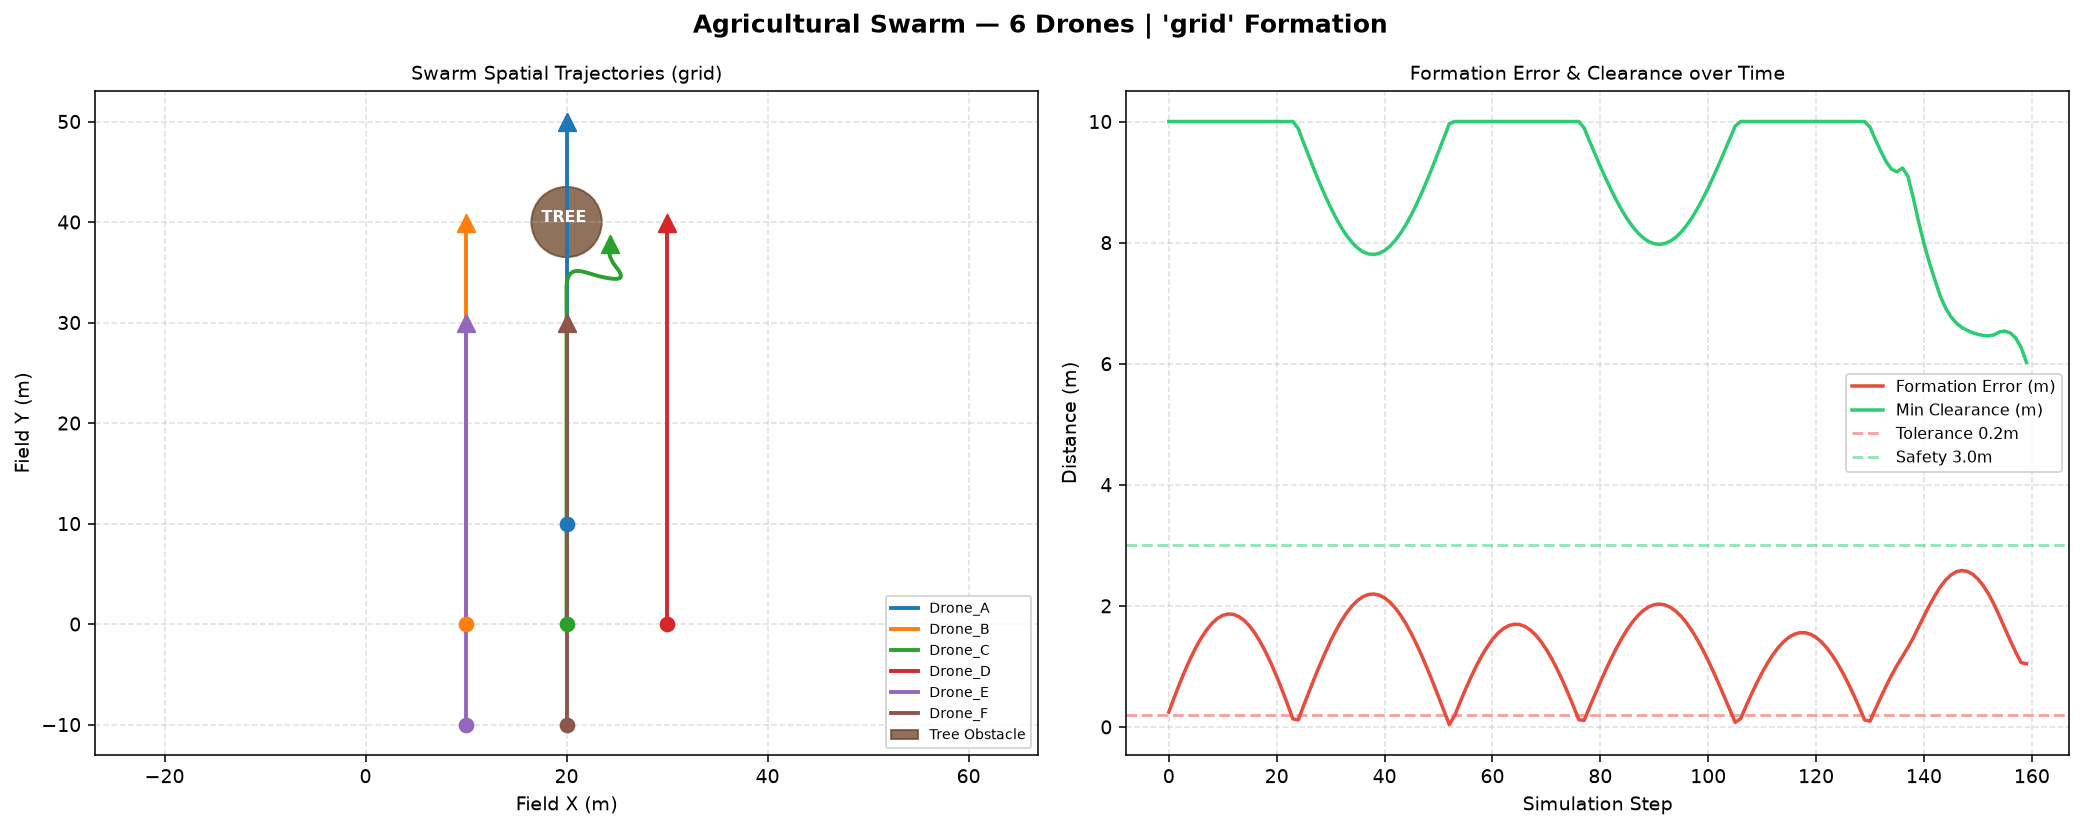

In [13]:
# ── Render trajectory plot ─────────────────────────────────────────────────
plot_path = "docs/swarm_trajectory_telemetry.png"
if os.path.exists(plot_path):
    display(Image(filename=plot_path))
else:
    print("Plot not found — ensure analyze_telemetry node ran successfully.")


## Conclusion

This v2 notebook demonstrates a proper **LangGraph StateGraph** architecture:

| Node | Type | Role |
|---|---|---|
| `assess_mission` | Deterministic | Load field + obstacle params |
| `plan_swarm` | **LLM (Gemini)** | Decide num_drones, formation, spacing |
| `dispatch_simulation` | Deterministic | Run physics simulation |
| `analyze_telemetry` | Deterministic | Compute metrics + save plot |
| `persist_telemetry` | Deterministic | Write to SQLite |
| `generate_verdict` | **LLM (Gemini)** | FDS compliance structured output |

**Key properties:**
- All state flows through typed `MissionState` TypedDict — no globals
- `InMemorySaver` checkpointer enables fault tolerance (resume from any node)
- SQLite `data/telemetry.db` persists metrics across sessions — query with `pandas.read_sql()`
- MLflow Databricks autologging captures all LLM calls + traces automatically
